# Approximate entropy under acute psilocybin

Companion to [`microstates.ipynb`](microstates.ipynb), for

> Novický, Stoliker, Razi & Zeldenrust, *EEG microstates transition more rapidly
> and approximate entropy increases under acute psilocybin*.

Approximate entropy (Pincus, 1991) measures how predictable a time series is:
how often short sub-sequences that match over $m$ samples still match over
$m+1$. Regular signals give low values, irregular ones high values. The method
is described in Methods 4.4.2 and Algorithm S1 of the paper; this notebook is
the implementation and the analysis built on it.

Parameters: $m = 2$, $r = 0.2$, non-overlapping 5 s windows, recordings
decimated from 500 Hz to 125 Hz, ApEn averaged over windows within each
electrode. Distances between template vectors use the Euclidean norm.
Electrodes rejected in preprocessing are reconstructed by spherical-spline
interpolation, so every recording carries all 64.

The notebook is self-contained: it runs end to end from `data/` and `results/`
without the raw recordings, and recomputes from them when they are available.

**Contents**

1. Implementation
2. Validation
3. The recordings
4. Computing ApEn for all recordings
5. Psilocybin vs baseline
6. Figure 2 — topographies

In [1]:
from __future__ import annotations

import json
import os
import re
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import scipy.stats
from joblib import Parallel, delayed
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from statsmodels.stats.multitest import fdrcorrection

DATA = Path("data")
FIGURES = Path("figures")
RESULTS = Path("results")
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

# ApEn parameters (Methods 4.4.2)
M = 2
R = 0.2
WINDOW_S = 5.0
ANALYSIS_SFREQ = 125.0
METRIC = "euclidean"
TOLERANCE = "normalized"

CONDITIONS = ("meditation", "video", "restingstate", "music")
CONDITION_LABELS = {"meditation": "Meditation", "video": "Video",
                    "restingstate": "Resting State", "music": "Music"}
ALPHA = 0.05

#: Where the raw recordings live, if you have them.  Only consulted when
#: RECOMPUTE is True; override with the PSICONNECT_ROOT environment variable.
PSICONNECT_ROOT = Path(os.environ.get("PSICONNECT_ROOT", "psiconnect"))

#: Set True to recompute from the recordings instead of loading the cached CSVs.
RECOMPUTE = False
N_JOBS = 8

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
})
print(f"mne {mne.__version__} | m={M} r={R} window={WINDOW_S}s "
      f"fs={ANALYSIS_SFREQ}Hz metric={METRIC}")

mne 1.10.1 | m=2 r=0.2 window=5.0s fs=125.0Hz metric=euclidean


## 1. Implementation

Each 5 s window is normalised to zero mean and unit standard deviation, so the
tolerance $r$ is applied on the same scale as the data being compared. Because
ApEn is scale invariant this is the same prescription as leaving the window in
microvolts and using $r\sigma$ — the standard deviation is divided out of the
data instead of multiplied into the threshold.

Template distances are built by combining $m$ diagonal-shifted copies of the
pairwise sample-distance matrix rather than by materialising the templates,
which is what makes 429 recordings tractable.

In [2]:
Metric = Literal["euclidean", "chebyshev"]
Tolerance = Literal["normalized", "raw_std"]


def pair_distance_stack(x: np.ndarray, metric: Metric) -> np.ndarray:
    """Per-sample pairwise term used to build template distances.

    ``A[i, j]`` is ``|x_i - x_j|`` for Chebyshev and ``(x_i - x_j) ** 2`` for
    Euclidean.  Template distances of embedding length ``m`` follow by combining
    ``m`` diagonal-shifted copies of ``A`` (max for Chebyshev, sum for
    Euclidean).
    """
    diff = x[:, None] - x[None, :]
    return np.abs(diff) if metric == "chebyshev" else diff * diff


def phi(pair: np.ndarray, m: int, n_templates: int, tol: float,
        metric: Metric) -> float:
    """Log-likelihood of template matches within tolerance ``tol``."""
    n = n_templates
    dist = pair[:n, :n].copy()
    for k in range(1, m):
        block = pair[k:k + n, k:k + n]
        if metric == "chebyshev":
            np.maximum(dist, block, out=dist)
        else:
            dist += block
    limit = tol if metric == "chebyshev" else tol * tol
    counts = (dist <= limit).sum(axis=1) / n
    return float(np.log(counts).sum() / n)


def apen_window(window: np.ndarray, m: int = M, r: float = R,
                metric: Metric = METRIC,
                tolerance: Tolerance = TOLERANCE) -> np.ndarray:
    """ApEn of every channel of a single window, shape ``(n_channels,)``.

    Channels that are constant within the window yield ``nan``.
    """
    if window.ndim != 2:
        raise ValueError(f"window must be 2-D, got {window.shape}")
    n_samples = window.shape[1]
    if n_samples < m + 2:
        raise ValueError(f"window of {n_samples} samples too short for m={m}")

    sd_raw = window.std(axis=1, ddof=1)
    valid = sd_raw > 0
    z = np.full_like(window, np.nan, dtype=float)
    z[valid] = ((window[valid] - window[valid].mean(axis=1, keepdims=True))
                / sd_raw[valid, None])

    if tolerance == "normalized":
        # z has unit standard deviation, so this is r itself; written out to
        # keep the definition visible.
        tol_per_channel = r * z[valid].std(axis=1, ddof=1)
    elif tolerance == "raw_std":
        tol_per_channel = r * sd_raw[valid]
    else:
        raise ValueError(f"unknown tolerance mode {tolerance!r}")

    out = np.full(window.shape[0], np.nan)
    for idx, tol in zip(np.flatnonzero(valid), tol_per_channel):
        pair = pair_distance_stack(z[idx], metric)
        out[idx] = (phi(pair, m, n_samples - m + 1, tol, metric)
                    - phi(pair, m + 1, n_samples - m, tol, metric))
    return out


def apen_multichannel(data: np.ndarray, sfreq: float = ANALYSIS_SFREQ,
                      m: int = M, r: float = R, window_s: float = WINDOW_S,
                      metric: Metric = METRIC,
                      tolerance: Tolerance = TOLERANCE) -> np.ndarray:
    """ApEn per channel, averaged over consecutive non-overlapping windows.

    Trailing samples that do not fill a whole window are discarded.
    """
    if data.ndim != 2:
        raise ValueError(f"data must be 2-D, got {data.shape}")
    width = int(round(window_s * sfreq))
    n_windows = data.shape[1] // width
    if n_windows == 0:
        raise ValueError(f"recording shorter than one {window_s}s window")

    per_window = np.stack(
        [apen_window(data[:, w * width:(w + 1) * width], m=m, r=r,
                     metric=metric, tolerance=tolerance)
         for w in range(n_windows)], axis=1)
    return np.nanmean(per_window, axis=1)

## 2. Validation

In [3]:
# Signals with a known ordering: a pure sine is perfectly predictable, white
# noise is not, and a noisy sine sits in between.
rng = np.random.default_rng(0)
t = np.arange(0, 20, 1 / ANALYSIS_SFREQ)

probes = {
    "sine (10 Hz)": np.sin(2 * np.pi * 10 * t),
    "sine + 20% noise": np.sin(2 * np.pi * 10 * t) + 0.2 * rng.standard_normal(t.size),
    "random walk": np.cumsum(rng.standard_normal(t.size)),
    "white noise": rng.standard_normal(t.size),
}
pd.Series({name: float(apen_multichannel(signal[None, :])[0])
           for name, signal in probes.items()}, name="ApEn").round(4).to_frame()

,ApEn
sine (10 Hz),0.2871
sine + 20% noise,1.4356
random walk,0.5717
white noise,1.4412


In [4]:
# ApEn is scale invariant: rescaling the input must not change the result.
scaled = {factor: float(apen_multichannel(probes["white noise"][None, :] * factor)[0])
          for factor in (1e-6, 1.0, 1e6)}
print("white noise at three input scales:", {k: round(v, 6) for k, v in scaled.items()})
assert np.ptp(list(scaled.values())) < 1e-12, "ApEn must not depend on the input units"

white noise at three input scales: {1e-06: 1.441207, 1.0: 1.441207, 1000000.0: 1.441207}


## 3. The recordings

The PsiConnect recordings are not part of this repository. The dataset is
openly available at <https://openneuro.org/datasets/ds006110/versions/1.2.0>,
and the preprocessed version used here can be obtained by contacting the
corresponding author. When present the recordings live under
`$PSICONNECT_ROOT` as
`{Control,Psilocybin}/{Meditation,Music,Resting state,Video}/*.set`, and dataset
identity is carried by the file name — `psi_sub007_restingstate` is session
`psi`, subject `sub007`, condition `restingstate`.

396 of the 429 recordings are missing at least one electrode and only 13 of the
64 are never rejected; T8 is absent from 204 recordings and T7 from 156. Left
missing, these would give every electrode a different sample size (46 to 182 in
the pooled contrast). They are therefore reconstructed from their neighbours by
spherical-spline interpolation so that every electrode contributes the same
number of pairs; section 5 shows this does not change the result.

In [5]:
#: Master 64-electrode list, in acquisition order.
ELECTRODES: tuple[str, ...] = (
    "FP1", "Fz", "F3", "F7", "FT9", "FC5", "FC1", "C3", "T7", "TP9", "CP5",
    "CP1", "Pz", "P3", "P7", "O1", "Oz", "O2", "P4", "P8", "TP10", "CP6",
    "CP2", "Cz", "C4", "T8", "FT10", "FC6", "FC2", "F4", "F8", "Fp2", "AF7",
    "AF3", "AFz", "F1", "F5", "FT7", "FC3", "C1", "C5", "TP7", "CP3", "P1",
    "P5", "PO7", "PO3", "POz", "PO4", "PO8", "P6", "P2", "CPz", "CP4", "TP8",
    "C6", "C2", "FC4", "FT8", "F6", "AF8", "AF4", "F2", "Iz",
)

_NAME_RE = re.compile(r"^(ctrl|psi)_(sub\d+)_([a-z]+)$")


@dataclass(frozen=True)
class Dataset:
    """One recording: a single subject, session and condition."""

    path: Path
    session: str
    subject: str
    condition: str

    @property
    def name(self) -> str:
        return f"{self.session}_{self.subject}_{self.condition}"


def find_datasets(root: Path = PSICONNECT_ROOT) -> list[Dataset]:
    """All ``.set`` recordings under ``root``, sorted by name."""
    if not root.is_dir():
        raise FileNotFoundError(f"PsiConnect root not found: {root}")
    datasets = []
    for path in sorted(root.rglob("*.set")):
        match = _NAME_RE.match(path.stem)
        if match is None:
            raise ValueError(f"unexpected file name: {path}")
        session, subject, condition = match.groups()
        if condition not in CONDITIONS:
            raise ValueError(f"unknown condition {condition!r} in {path}")
        datasets.append(Dataset(path, session, subject, condition))
    if not datasets:
        raise FileNotFoundError(f"no .set files under {root}")
    return datasets


def electrode_positions() -> dict[str, np.ndarray]:
    """3-D head-frame positions of the 64 electrodes."""
    with open(DATA / "corrected_electrode_locations.json") as handle:
        raw = json.load(handle)
    lookup = {name.lower(): np.array([raw[name][a] for a in ("x", "y", "z")])
              for name in raw}
    return {e: lookup[e.lower()] for e in ELECTRODES}


def interpolate_missing(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
    """Return a 64-channel recording, absent electrodes filled by spline."""
    present = {c.lower(): c for c in raw.ch_names}
    absent = [e for e in ELECTRODES if e.lower() not in present]
    if not absent:
        return raw

    data = np.zeros((len(ELECTRODES), raw.n_times))
    for i, e in enumerate(ELECTRODES):
        if e.lower() in present:
            data[i] = raw.get_data(picks=[present[e.lower()]])[0]

    info = mne.create_info(list(ELECTRODES), raw.info["sfreq"], "eeg")
    info.set_montage(mne.channels.make_dig_montage(
        ch_pos=electrode_positions(), coord_frame="head"))
    filled = mne.io.RawArray(data, info, verbose="error")
    filled.info["bads"] = absent
    filled.interpolate_bads(reset_bads=True, verbose="error")
    return filled


def load_eeg(dataset: Dataset, sfreq: float = ANALYSIS_SFREQ,
             interpolate: bool = True) -> tuple[np.ndarray, list[str]]:
    """Load one recording, decimated to ``sfreq``, in microvolts."""
    raw = mne.io.read_raw_eeglab(dataset.path, preload=True, verbose="error")
    if not np.isclose(raw.info["sfreq"], sfreq):
        raw.resample(sfreq, verbose="error")
    if interpolate:
        raw = interpolate_missing(raw)
    return raw.get_data() * 1e6, list(raw.ch_names)


def align_to_master(values: np.ndarray, channel_names: list[str]) -> np.ndarray:
    """Reindex per-channel values onto ELECTRODES, NaN where absent."""
    lookup = {n.lower(): v for n, v in zip(channel_names, values)}
    return np.array([lookup.get(e.lower(), np.nan) for e in ELECTRODES])

## 4. Computing ApEn for all recordings

`data/apen.csv` ships with the repository — for a reader without the raw
recordings it is an input, not an output — so this section loads it and does not
touch the recordings. Set `RECOMPUTE = True` in the configuration cell to
recompute: about 5 s per recording, so roughly 5 minutes at `N_JOBS = 8`.

In [6]:
def compute_apen_matrix(interpolate: bool, n_jobs: int = N_JOBS) -> pd.DataFrame:
    """ApEn for every recording, as a (64 electrodes x N recordings) frame."""
    datasets = find_datasets()
    print(f"computing ApEn over {len(datasets)} recordings "
          f"(interpolate={interpolate}, n_jobs={n_jobs})", flush=True)

    def one(dataset: Dataset) -> np.ndarray:
        data, names = load_eeg(dataset, interpolate=interpolate)
        return align_to_master(apen_multichannel(data), names)

    started = time.time()
    values = Parallel(n_jobs=n_jobs)(delayed(one)(d) for d in datasets)
    print(f"finished in {(time.time() - started) / 60:.1f} min")
    return pd.DataFrame({d.name: v for d, v in zip(datasets, values)},
                        index=pd.Index(ELECTRODES, name="Electrode"))


def load_or_compute(path: Path, interpolate: bool) -> pd.DataFrame:
    """Load a cached ApEn matrix, or recompute and cache it."""
    if path.exists() and not RECOMPUTE:
        print(f"loaded cached {path}")
        return pd.read_csv(path, index_col=0)
    matrix = compute_apen_matrix(interpolate=interpolate)
    matrix.to_csv(path)
    print(f"wrote {path}")
    return matrix


apen = load_or_compute(DATA / "apen.csv", interpolate=True)
print(f"{apen.shape[0]} electrodes x {apen.shape[1]} recordings")
print(f"ApEn range {np.nanmin(apen.values):.3f} to {np.nanmax(apen.values):.3f}, "
      f"mean {np.nanmean(apen.values):.3f}")
apen.iloc[:5, :4].round(4)

loaded cached data/apen.csv
64 electrodes x 429 recordings
ApEn range 0.924 to 1.526, mean 1.377


,ctrl_sub001_meditation,ctrl_sub002_meditation,ctrl_sub003_meditation,ctrl_sub004_meditation
Electrode,,,,
FP1,1.3076,1.4522,1.4565,1.3546
Fz,1.1308,1.4483,1.4489,1.1848
F3,1.2218,1.4593,1.4549,1.1866
F7,1.3553,1.4667,1.4676,1.2373
FT9,1.2225,1.4613,1.4583,1.2048


In [7]:
# The complete-case variant, used for the sensitivity check in section 5.
complete_case = load_or_compute(DATA / "apen_complete_case.csv",
                                interpolate=False)

assert not apen.isna().any().any(), "every recording should carry all 64 electrodes"
reconstructed = complete_case.isna()
print(f"\nreconstructed cells: {int(reconstructed.sum().sum())} of {apen.size} "
      f"({100 * reconstructed.sum().sum() / apen.size:.1f}%)")
print("\nmost frequently reconstructed electrodes:")
print(reconstructed.sum(axis=1).sort_values(ascending=False).head(6).to_string())

loaded cached data/apen_complete_case.csv

reconstructed cells: 1695 of 27456 (6.2%)

most frequently reconstructed electrodes:
Electrode
T8      204
T7      156
TP10    117
TP9     112
C6       74
FT8      64


## 5. Psilocybin vs baseline

The design is within-participant: every subject contributes a baseline and a
psilocybin recording of the same condition. Recordings are paired on
(subject, condition), compared per electrode with a paired t-test, and corrected
with Benjamini–Hochberg across the 64 electrodes within each condition.
"Overall" pools all four conditions, so a participant may contribute up to four
pairs to it.

In [8]:
def dataset_metadata(names: list[str]) -> pd.DataFrame:
    """Split dataset names into session / subject / condition."""
    parts = pd.Series(names).str.extract(
        r"^(?P<session>ctrl|psi)_(?P<subject>sub\d+)_(?P<condition>[a-z]+)$")
    parts.index = names
    if parts.isna().any().any():
        raise ValueError("unparseable dataset names")
    return parts


def paired_columns(meta: pd.DataFrame, condition: str | None = None
                   ) -> tuple[list[str], list[str]]:
    """Column names of matched (baseline, psilocybin) recordings, aligned."""
    subset = meta if condition is None else meta[meta["condition"] == condition]
    baseline = subset[subset["session"] == "ctrl"]
    drug = subset[subset["session"] == "psi"]
    key = ["subject", "condition"]
    shared = (baseline.reset_index().merge(drug.reset_index(), on=key,
                                           suffixes=("_ctrl", "_psi"))
                      .sort_values(key))
    return list(shared["index_ctrl"]), list(shared["index_psi"])


def compare_electrodes(matrix: pd.DataFrame, meta: pd.DataFrame,
                       condition: str | None) -> pd.DataFrame:
    """Paired t-test per electrode, FDR-corrected across electrodes."""
    ctrl_cols, psi_cols = paired_columns(meta, condition)
    rows = []
    for electrode in matrix.index:
        pair = pd.DataFrame({
            "ctrl": matrix.loc[electrode, ctrl_cols].to_numpy(dtype=float),
            "psi": matrix.loc[electrode, psi_cols].to_numpy(dtype=float),
        }).dropna()
        if len(pair) < 3:
            rows.append({"Electrode": electrode, "n": len(pair),
                         "difference": np.nan, "d_z": np.nan,
                         "t": np.nan, "p": np.nan})
            continue
        delta = pair["psi"] - pair["ctrl"]
        result = scipy.stats.ttest_rel(pair["psi"], pair["ctrl"])
        rows.append({"Electrode": electrode, "n": len(pair),
                     "difference": float(delta.mean()),
                     "d_z": float(delta.mean() / delta.std(ddof=1)),
                     "t": float(result.statistic), "p": float(result.pvalue)})

    out = pd.DataFrame(rows).set_index("Electrode")
    usable = out["p"].notna()
    out["FDR"] = np.nan
    out.loc[usable, "FDR"] = fdrcorrection(out.loc[usable, "p"], alpha=ALPHA)[1]
    out["significant"] = out["FDR"] < ALPHA
    return out


meta = dataset_metadata(list(apen.columns))
CONTRASTS = [("Overall", None)] + [(CONDITION_LABELS[c], c) for c in CONDITIONS]
stats = {label: compare_electrodes(apen, meta, condition)
         for label, condition in CONTRASTS}

summary = pd.DataFrame({
    "electrodes tested": {k: int(v["p"].notna().sum()) for k, v in stats.items()},
    "significant (FDR < .05)": {k: int(v["significant"].sum()) for k, v in stats.items()},
    "mean ΔApEn": {k: round(v["difference"].mean(), 4) for k, v in stats.items()},
    "mean d_z": {k: round(v["d_z"].mean(), 3) for k, v in stats.items()},
    "n per electrode": {k: int(v["n"].max()) for k, v in stats.items()},
})
summary.to_csv(RESULTS / "apen_summary.csv")
summary

,electrodes tested,significant (FDR < .05),mean ΔApEn,mean d_z,n per electrode
Overall,64,64,0.0506,0.694,182
Meditation,64,64,0.0607,0.780,51
Video,64,8,0.0066,0.172,34
Resting State,64,64,0.0738,1.044,48
Music,64,64,0.0480,0.656,49


### Sensitivity to the interpolation

Repeating everything with the rejected electrodes left missing, so that pairs
are formed only where an electrode is present in both sessions. If
interpolation were driving the result, the two would disagree.

In [9]:
complete_case_stats = {label: compare_electrodes(complete_case, meta, condition)
                       for label, condition in CONTRASTS}

comparison = pd.DataFrame({
    "significant (interpolated)":
        {k: int(v["significant"].sum()) for k, v in stats.items()},
    "significant (complete case)":
        {k: int(v["significant"].sum()) for k, v in complete_case_stats.items()},
    "mean ΔApEn (interpolated)":
        {k: round(v["difference"].mean(), 4) for k, v in stats.items()},
    "mean ΔApEn (complete case)":
        {k: round(v["difference"].mean(), 4) for k, v in complete_case_stats.items()},
    "n (interpolated)": {k: int(v["n"].max()) for k, v in stats.items()},
    "n (complete case)": {k: f"{int(v['n'].min())}–{int(v['n'].max())}"
                          for k, v in complete_case_stats.items()},
})
comparison.to_csv(RESULTS / "apen_interpolation_sensitivity.csv")
comparison

,significant (interpolated),significant (complete case),mean ΔApEn (interpolated),mean ΔApEn (complete case),n (interpolated),n (complete case)
Overall,64,64,0.0506,0.0514,182,46–182
Meditation,64,64,0.0607,0.0620,51,14–51
Video,8,9,0.0066,0.0072,34,8–34
Resting State,64,64,0.0738,0.0734,48,12–48
Music,64,64,0.0480,0.0491,49,12–49


In [10]:
for label, table in stats.items():
    table.to_csv(RESULTS / f"apen_stats_{label.lower().replace(' ', '_')}.csv")
pd.concat(stats, names=["Contrast"]).to_csv(RESULTS / "apen_stats.csv")

print("largest psilocybin-minus-baseline increases (Overall):")
print(stats["Overall"].sort_values("difference", ascending=False)
      [["n", "difference", "d_z", "t", "FDR", "significant"]].head(8).round(4).to_string())

print("\nsignificant electrodes in the video condition:")
video = stats["Video"]
print(video[video["significant"]].sort_values("FDR")
      [["n", "difference", "d_z", "FDR"]].round(4).to_string())

largest psilocybin-minus-baseline increases (Overall):
             n  difference     d_z        t  FDR  significant
Electrode                                                    
P8         182      0.0865  0.9125  12.3096  0.0         True
PO8        182      0.0862  0.7799  10.5216  0.0         True
PO7        182      0.0850  0.7897  10.6533  0.0         True
O1         182      0.0785  0.7630  10.2938  0.0         True
O2         182      0.0784  0.7874  10.6221  0.0         True
P6         182      0.0774  0.8144  10.9873  0.0         True
P5         182      0.0763  0.9149  12.3429  0.0         True
PO4        182      0.0751  0.7320   9.8752  0.0         True

significant electrodes in the video condition:
            n  difference     d_z     FDR
Electrode                                
O2         34      0.0325  0.9270  0.0004
P8         34      0.0279  0.8296  0.0010
PO4        34      0.0273  0.7273  0.0036
Oz         34      0.0304  0.6900  0.0050
PO8        34      0.0254

## 6. Figure 2 — topographies

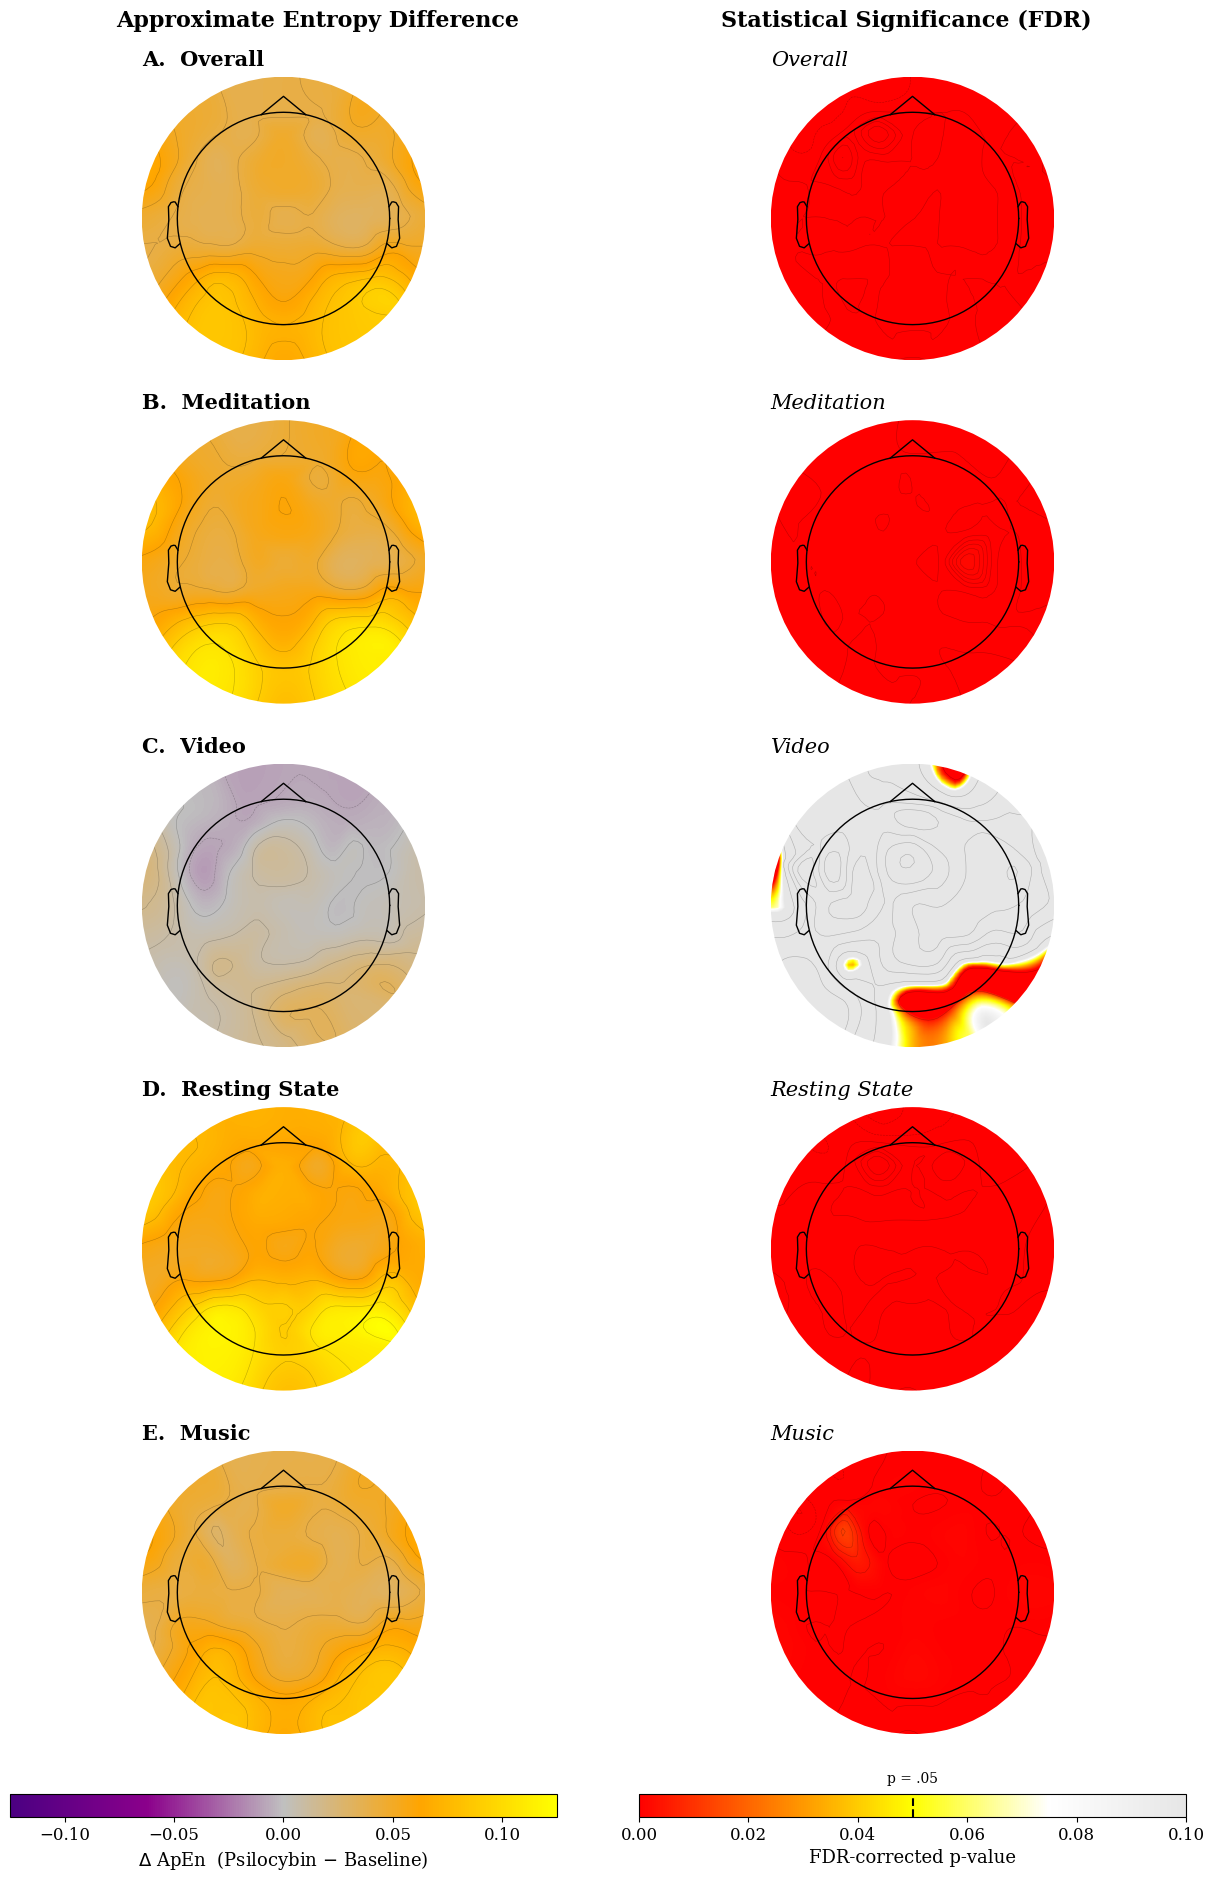

In [11]:
info = mne.create_info(ch_names=list(ELECTRODES), sfreq=ANALYSIS_SFREQ, ch_types="eeg")
info.set_montage(mne.channels.make_dig_montage(ch_pos=electrode_positions(),
                                               coord_frame="head"))

apen_cmap = LinearSegmentedColormap.from_list(
    "apen", ["#4B0082", "#8B008B", "#C0C0C0", "#FFA500", "#FFFF00"], N=256)
pvalue_cmap = LinearSegmentedColormap.from_list(
    "pvalue", ["#FF0000", "#FF8000", "#FFFF00", "#FFFFFF", "#E6E6E6"], N=256)

differences = np.concatenate([t.loc[list(ELECTRODES), "difference"].to_numpy()
                              for t in stats.values()])
limit = float(np.ceil(np.nanmax(np.abs(differences)) * 40) / 40)

fig = plt.figure(figsize=(14, 20))
grid = GridSpec(6, 2, figure=fig, height_ratios=[1, 1, 1, 1, 1, 0.08],
                hspace=0.25, wspace=0.15, left=0.08, right=0.92,
                top=0.93, bottom=0.06)

fig.text(0.30, 0.955, "Approximate Entropy Difference", fontsize=16,
         ha="center", weight="bold")
fig.text(0.72, 0.955, "Statistical Significance (FDR)", fontsize=16,
         ha="center", weight="bold")

for row, (label, table) in enumerate(stats.items()):
    ax_left = fig.add_subplot(grid[row, 0])
    image, contours = mne.viz.plot_topomap(
        table.loc[list(ELECTRODES), "difference"].to_numpy(), info, axes=ax_left,
        show=False, cmap=apen_cmap, sensors=False, contours=6,
        vlim=(-limit, limit))
    contours.set_alpha(0.25)
    contours.set_linewidths(0.4)
    ax_left.set_title(f"{chr(65 + row)}.  {label}", fontsize=15, pad=8,
                      loc="left", weight="bold")

    ax_right = fig.add_subplot(grid[row, 1])
    image_p, contours_p = mne.viz.plot_topomap(
        table.loc[list(ELECTRODES), "FDR"].to_numpy(), info, axes=ax_right,
        show=False, cmap=pvalue_cmap, sensors=False, contours=6, vlim=(0.0, 0.1))
    contours_p.set_alpha(0.25)
    contours_p.set_linewidths(0.4)
    ax_right.set_title(label, fontsize=15, pad=8, loc="left", style="italic")

bar_left = fig.colorbar(image, cax=fig.add_subplot(grid[5, 0]),
                        orientation="horizontal")
bar_left.set_label(r"$\Delta$ ApEn  (Psilocybin $-$ Baseline)", fontsize=13)

bar_right = fig.colorbar(image_p, cax=fig.add_subplot(grid[5, 1]),
                         orientation="horizontal")
bar_right.set_label("FDR-corrected p-value", fontsize=13)
bar_right.ax.axvline(ALPHA, color="k", linestyle="--", linewidth=1.5)
bar_right.ax.text(ALPHA, 1.35, "p = .05", transform=bar_right.ax.transData,
                  fontsize=10, ha="center", va="bottom")

fig.savefig(FIGURES / "figure2_apen_topomaps.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES / "figure2_apen_topomaps.pdf", bbox_inches="tight")
plt.show()

Topographical maps of the psilocybin-minus-baseline difference in approximate
entropy (left) and the corresponding FDR-corrected p-values (right), for all
conditions pooled (A) and for each condition separately (B–E). Yellow indicates
higher ApEn in the psilocybin session; darker red indicates stronger evidence
against the null.